In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../csv_files/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.shape

(768, 9)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
#Check missing value
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df[cols] = df[cols].replace(0, np.nan)

In [9]:
df.fillna(df.mean(), inplace=True)

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

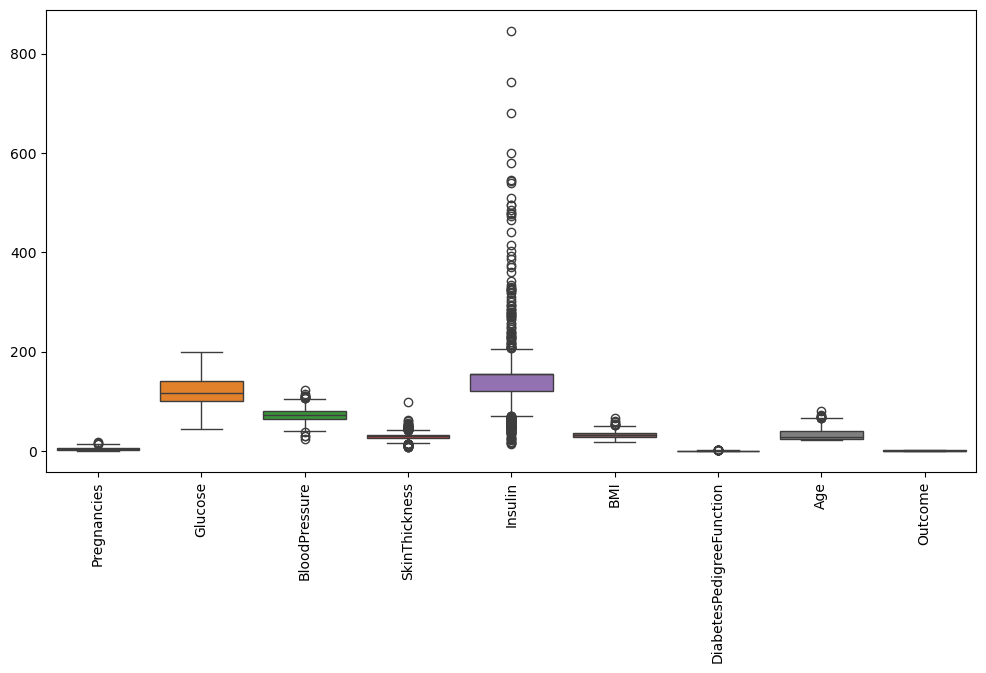

In [11]:
#outlier ditection
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [12]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

# Apply capping to all numeric columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    cap_outliers(df, col)

print("Outliers capped successfully!")

Outliers capped successfully!


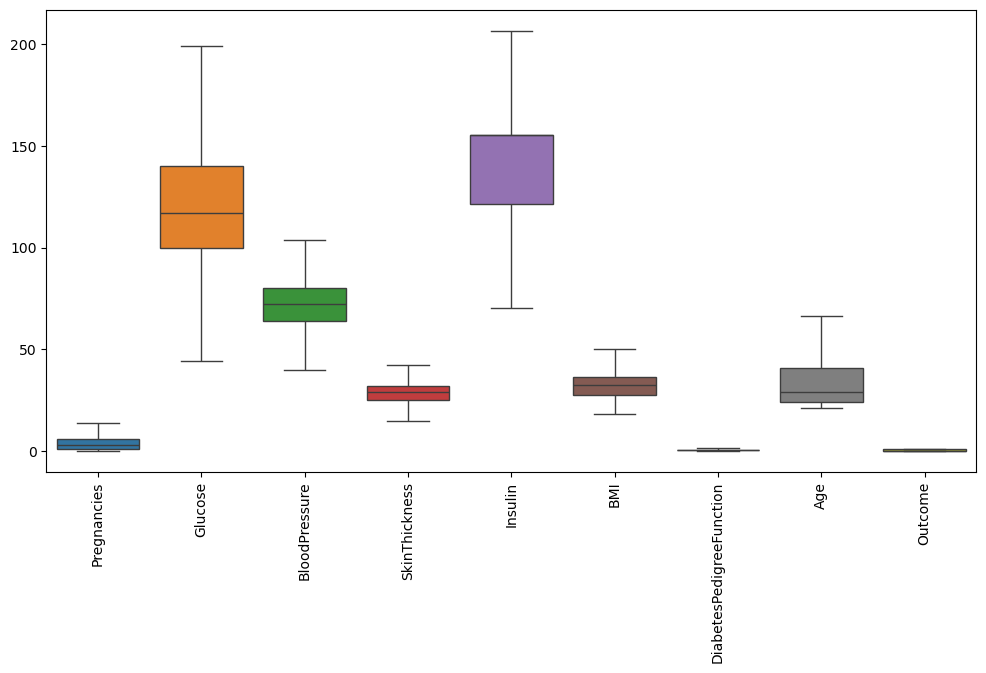

In [13]:
#outlier ditection
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

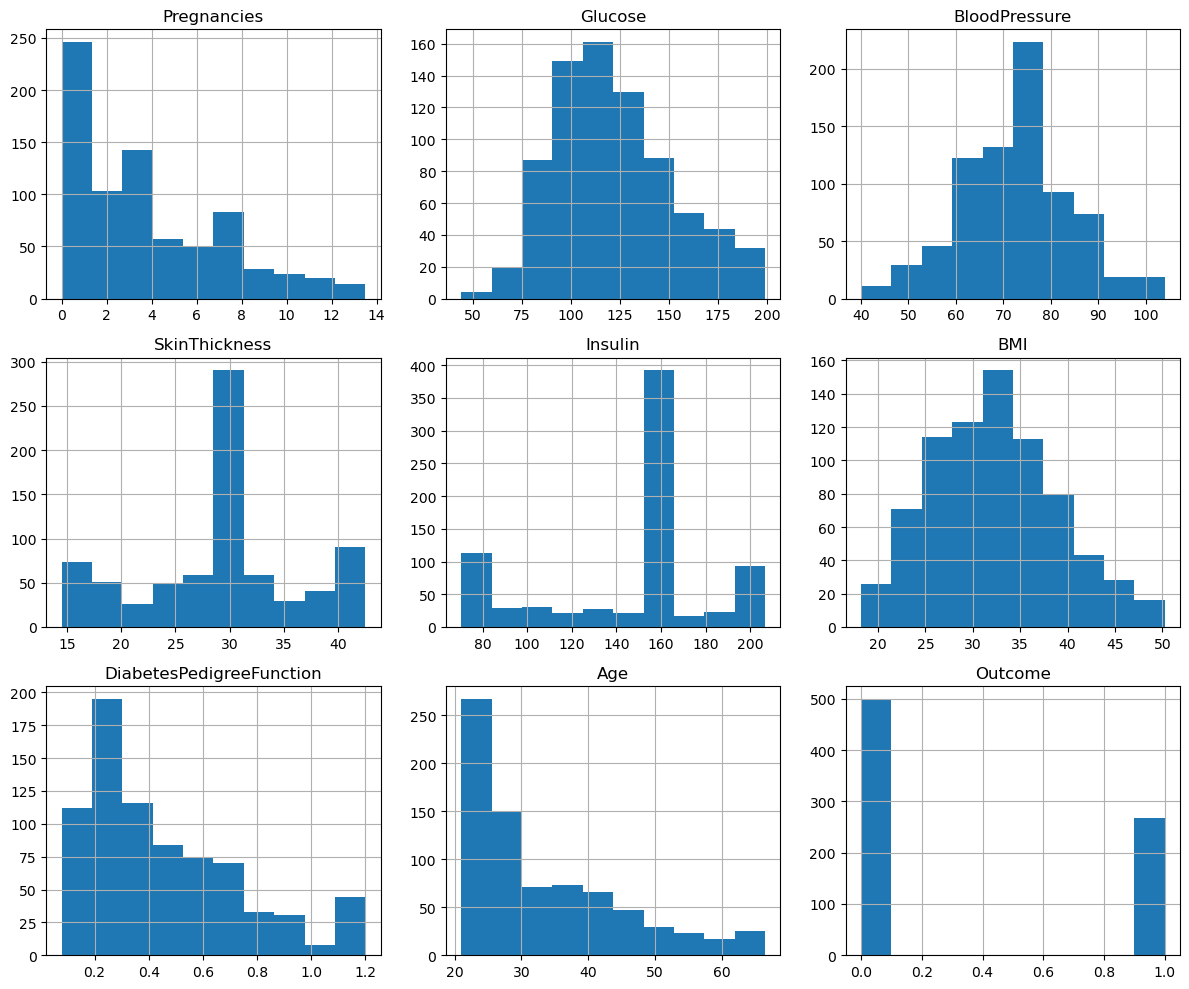

In [14]:
#Histogram
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

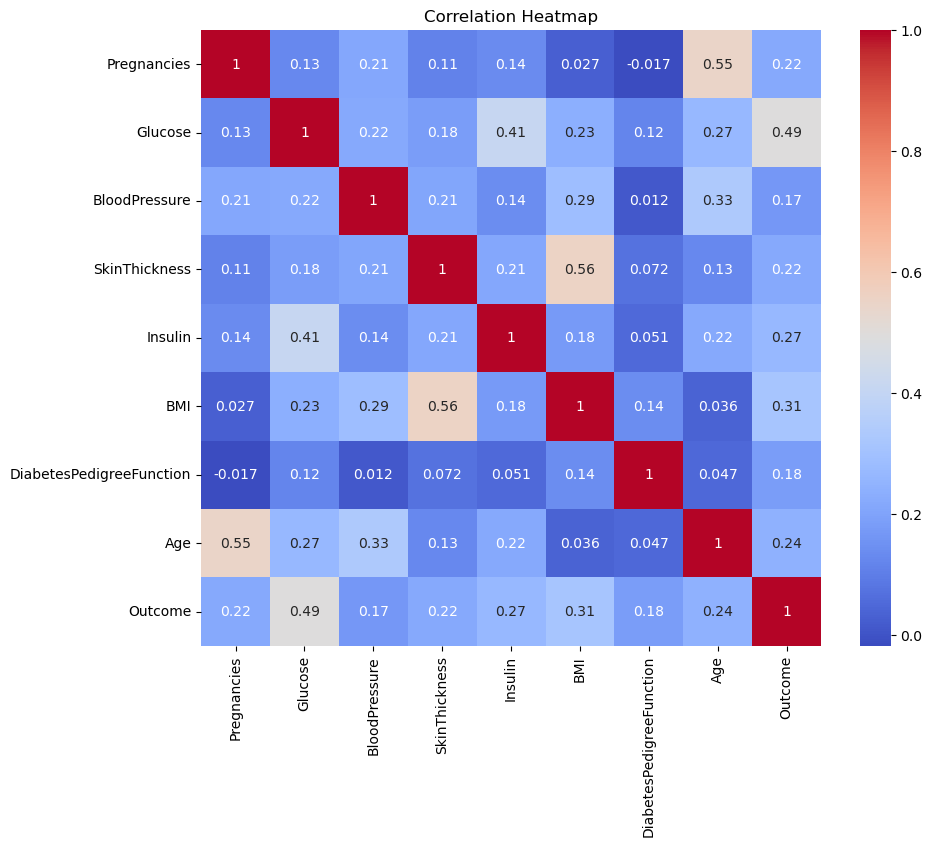

In [15]:
#correlation metrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

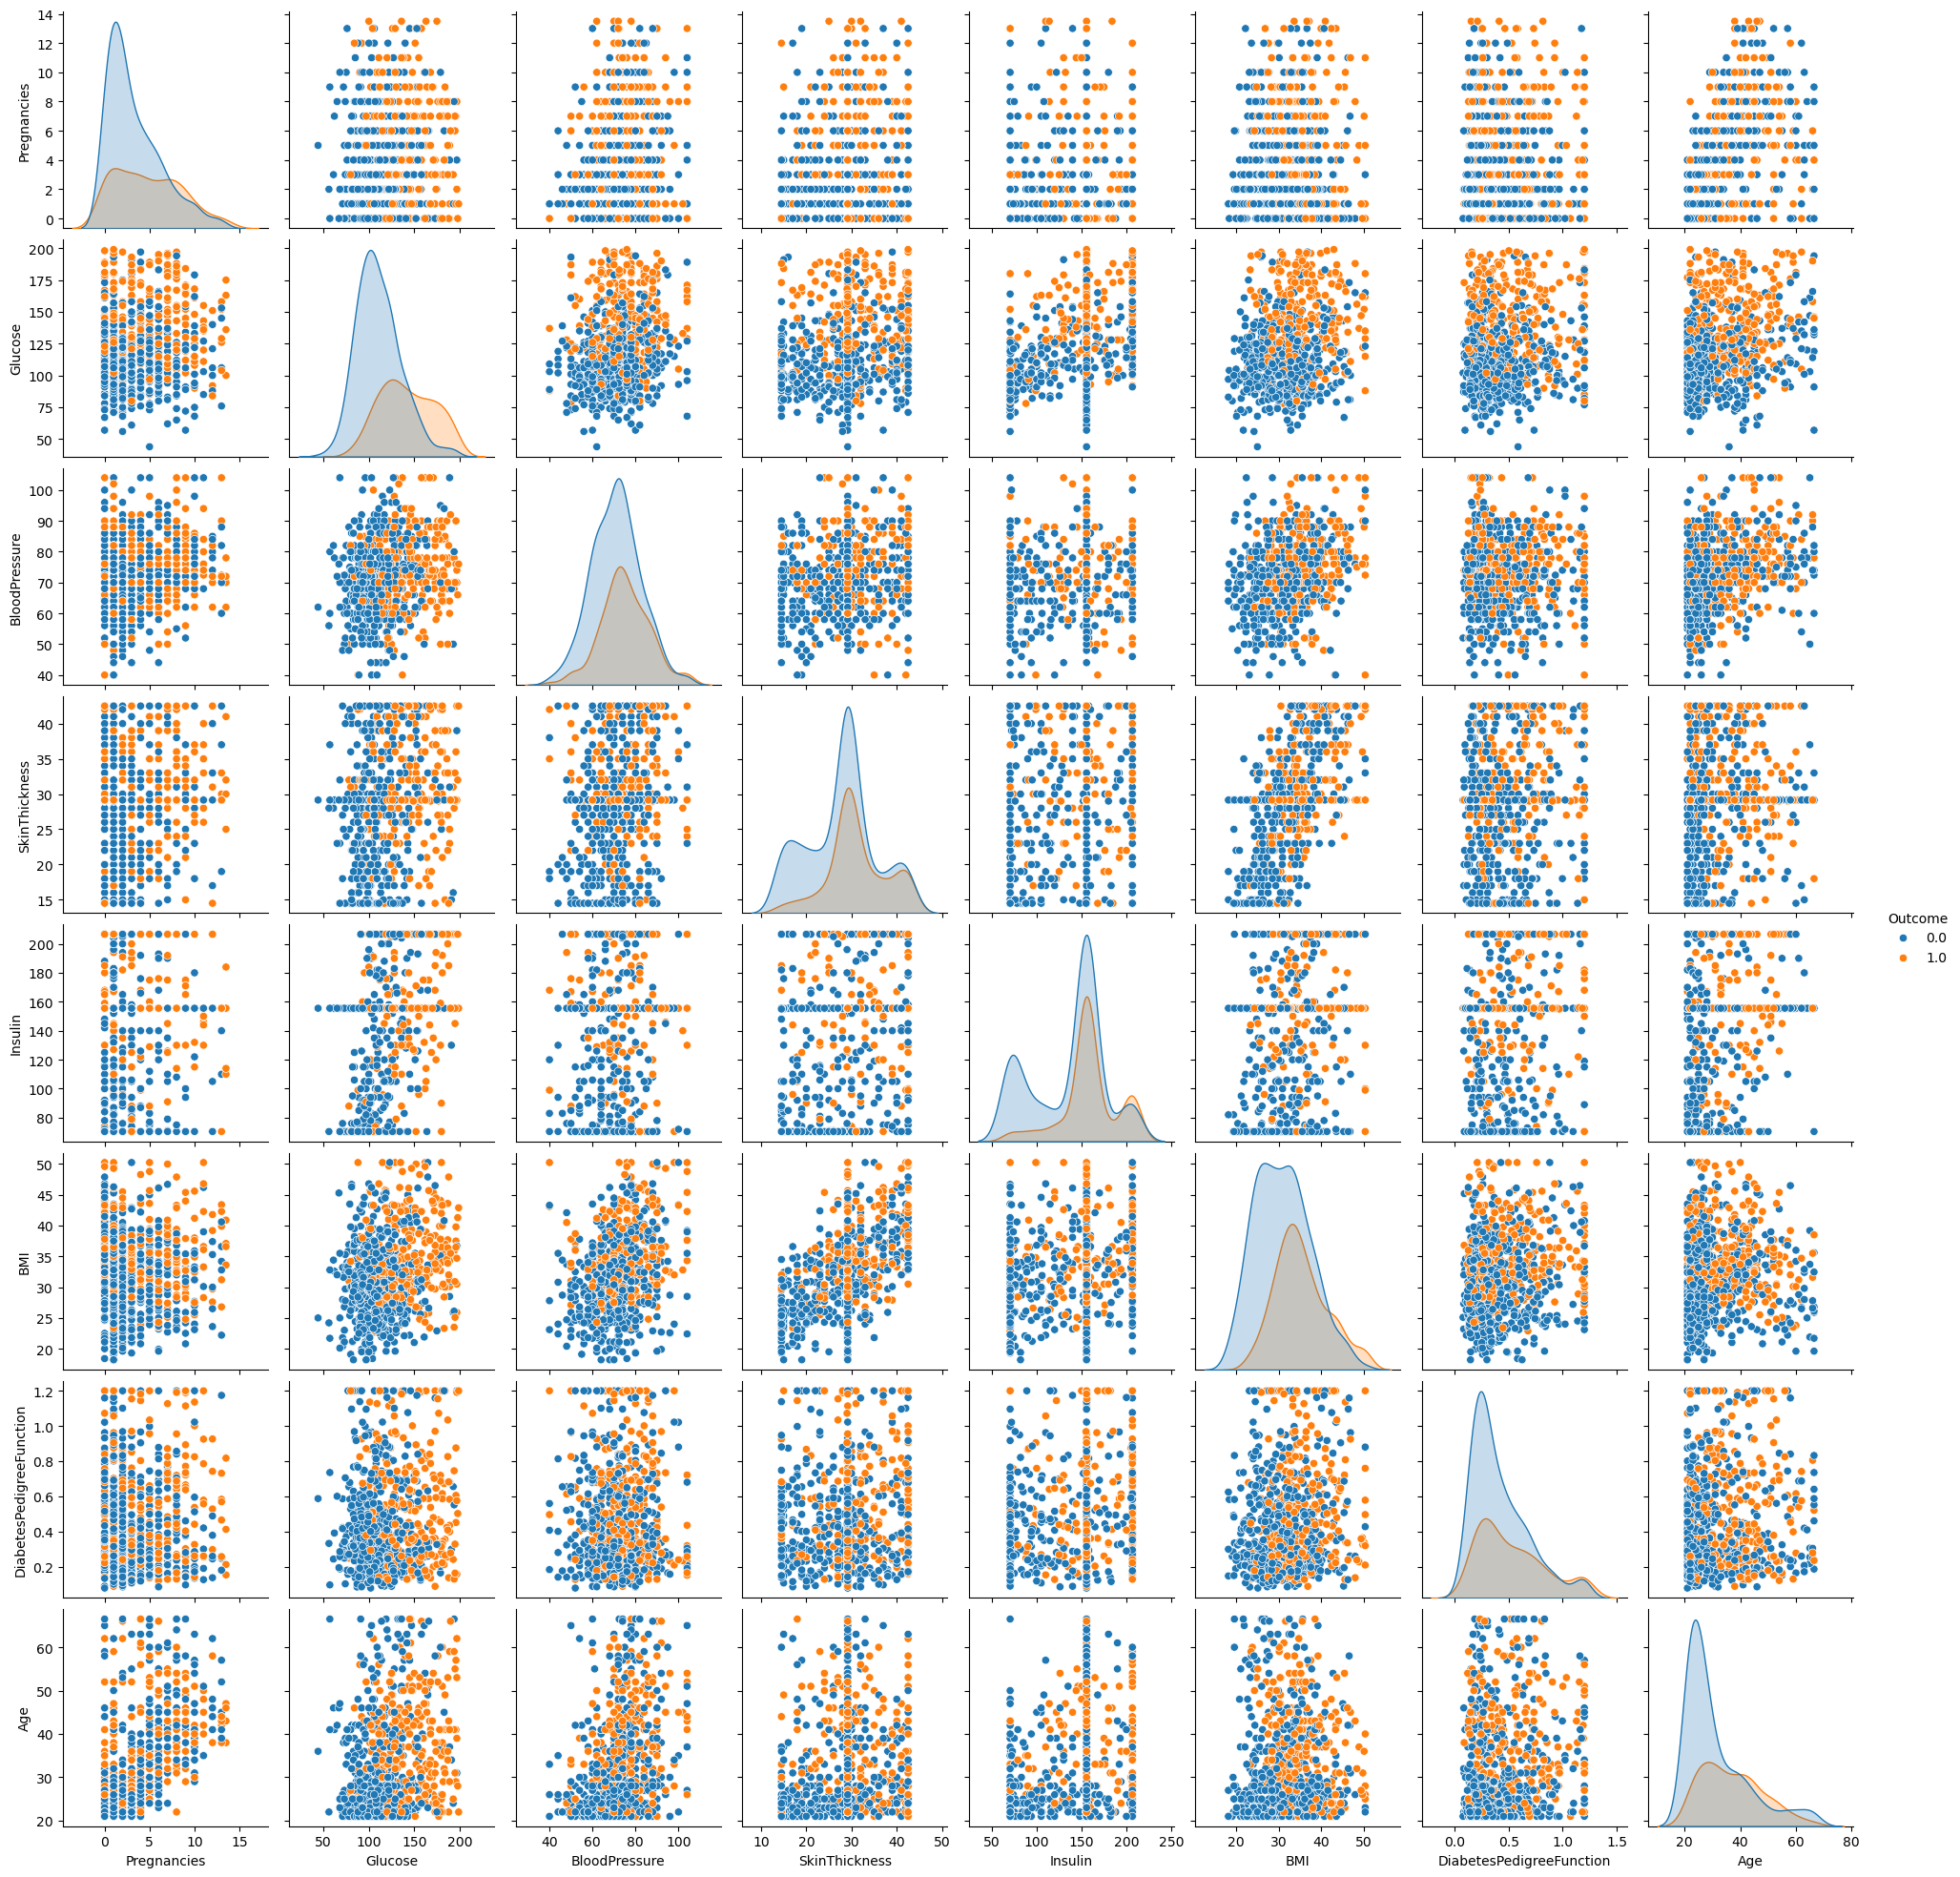

In [16]:
sns.pairplot(df, hue="Outcome")

plt.show()

In [17]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [18]:
#Train Text Split 
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [19]:
#StanderScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
#Logistic Model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


In [23]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.660377358490566


In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


In [25]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.660377358490566


In [26]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.6363636363636364


In [27]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.6481481481481481


In [28]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8255280073461891


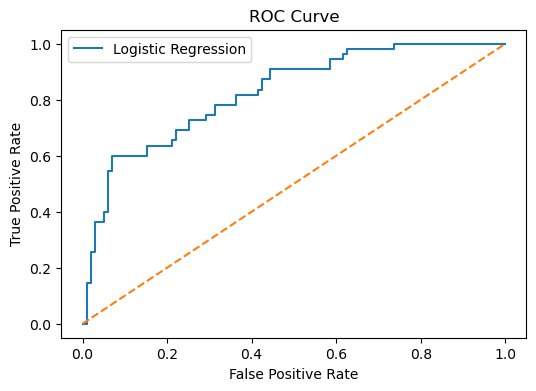

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [30]:
coefficients = pd.DataFrame({

"Feature":X.columns,

"Coefficient":model.coef_[0]

})

print(coefficients)

                    Feature  Coefficient
0               Pregnancies     0.205889
1                   Glucose     0.997257
2             BloodPressure    -0.151133
3             SkinThickness     0.068208
4                   Insulin     0.141829
5                       BMI     0.651125
6  DiabetesPedigreeFunction     0.249639
7                       Age     0.413148


In [31]:
import pickle

# Save model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save scaler if used
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

Interview Questions:



1. What is the difference between precision and recall?
   
Ans: 
Precision tells how many of the predicted positive cases are actually positive.

Recall tells how many of the actual positive cases the model was able to detect.

Precision → focuses on reducing False Positives

Recall → focuses on reducing False Negatives


Precision = “How accurate are positive predictions?”

Recall = “How many real positives did we catch?”

2.What is cross-validation, and why is it important in binary classification?

Ans :
Cross-validation is a technique where the dataset is split into multiple parts (folds), and the model is trained and tested multiple times.

The final performance is the average of all folds.

Why important?

Gives more reliable and stable accuracy

Reduces overfitting

Uses data efficiently

Helps select the best model

![Screenshot](Assigment/Screenshot (157).png)